# ResNet Artifact Visualizer

This notebook reads the locally saved ResNet evaluation artifacts and builds quick plots for presentation and analysis. It does not rerun training.

In [1]:
from pathlib import Path
import sys


def find_repo_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists() or (candidate / "artifacts").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.artifact_visualizer import display_artifact_dashboard


## ResNet18 Artifact Dashboard

Using saved artifacts from `artifacts\ResNet18\V17\evaluation_artifacts\resnet18_ex17`

### Summary Metrics

,Metric,Score (%)
0,Validation Accuracy,84.84
1,Macro Precision,76.68
2,Macro Recall,69.86
3,Macro F1,72.28
4,Weighted F1,84.40


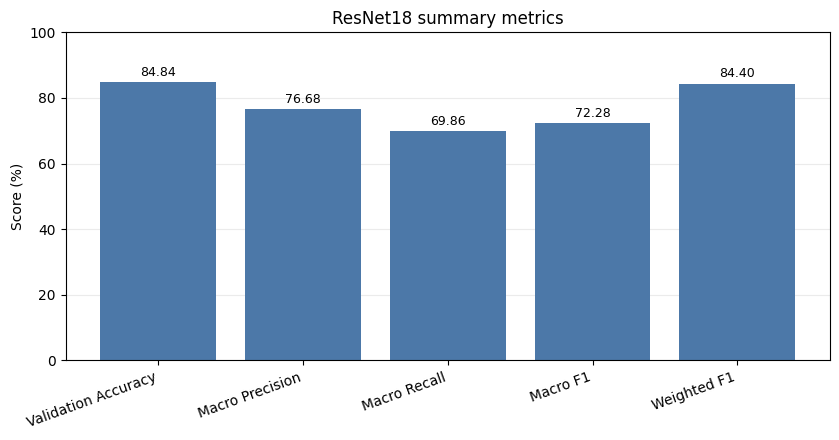

### Training Curves

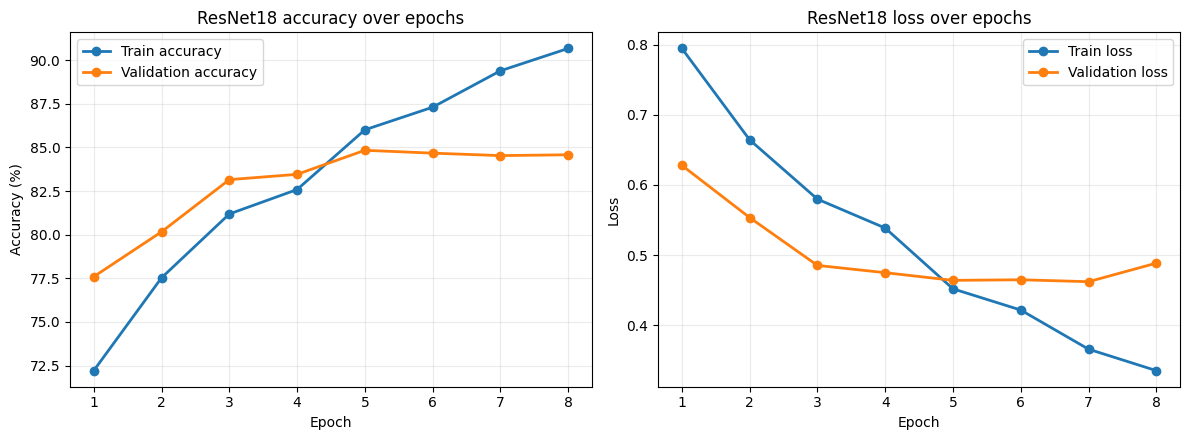

### Per-Class Metrics

,precision,recall,f1-score,support
Cassava Bacterial Blight (CBB),0.636,0.475,0.544,217.0
Cassava Brown Streak Disease (CBSD),0.791,0.667,0.724,438.0
Cassava Green Mottle (CGM),0.865,0.606,0.713,477.0
Cassava Mosaic Disease (CMD),0.919,0.967,0.942,2632.0
Healthy,0.622,0.779,0.692,516.0


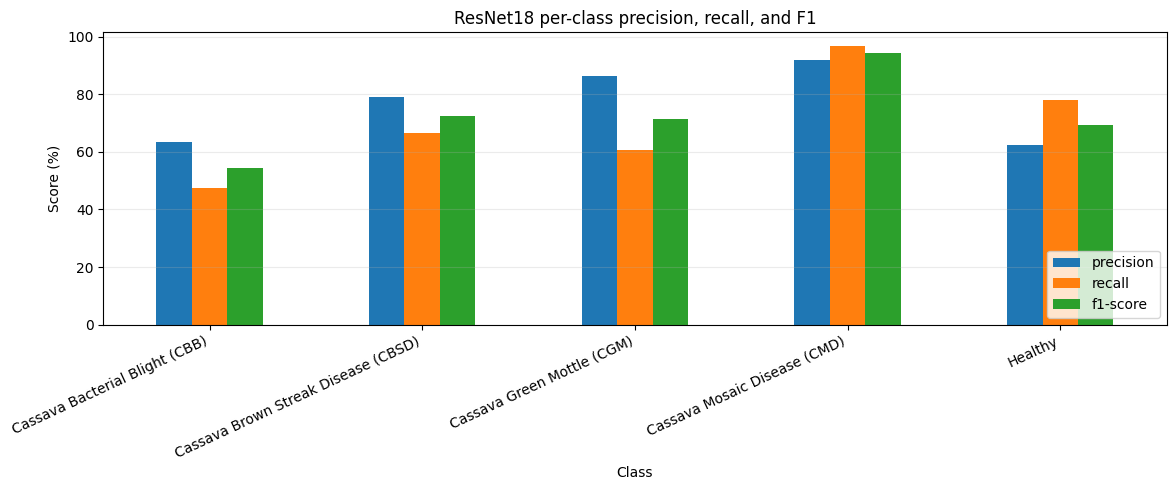

### Confusion Matrix

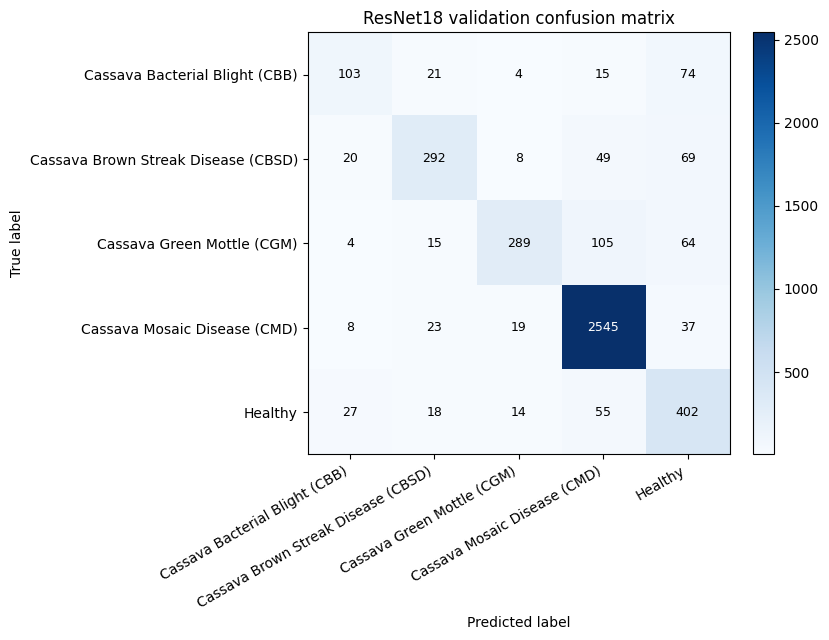

### Highest-Confidence Validation Mistakes

,image_id,true_name,pred_name,label,pred_label,confidence
2018,3308428199.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.996964
604,69869891.jpg,Healthy,Cassava Mosaic Disease (CMD),4,3,0.996678
1413,3254381404.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.996160
3611,2191616657.jpg,Healthy,Cassava Mosaic Disease (CMD),4,3,0.995127
740,2964319583.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.994598
1352,1184986094.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.993493
1747,2074036389.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.993390
2777,3689984405.jpg,Cassava Brown Streak Disease (CBSD),Healthy,1,4,0.991459
203,542786109.jpg,Cassava Green Mottle (CGM),Healthy,2,4,0.990861
3923,2872388134.jpg,Cassava Green Mottle (CGM),Cassava Mosaic Disease (CMD),2,3,0.990066


In [2]:
MODEL_FAMILY = "ResNet18"
PREFERRED_SUBDIR = "V17"
ARTIFACT_DIR_OVERRIDE = None
# Example override:
# ARTIFACT_DIR_OVERRIDE = repo_root / "artifacts" / "ResNet18" / "V17" / "evaluation_artifacts" / "resnet18_ex17"

try:
    artifact_bundle = display_artifact_dashboard(
        model_family=MODEL_FAMILY,
        preferred_subdir=PREFERRED_SUBDIR,
        override=ARTIFACT_DIR_OVERRIDE,
    )
except FileNotFoundError as exc:
    print(exc)
